In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

from utils import parse_latencies, parse_power_log

In [2]:
DATA_PATH = Path('../../raw_data/power_profile_between_inference')
DELAY = 1 # delay introduced in seconds between inference cycles

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4176107.2315945667


## VGG16

In this section, we will analyse the power consumption of VGG16 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [4]:
model_name = 'vgg16'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
vgg16_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
vgg16_latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:01<00:00, 36.87it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(vgg16_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(vgg16_latency_data[0])}")
layer = list(data.keys())[0]
print(f"Number of latency entries for each layer: {len(vgg16_latency_data)}")

Number of power entries for vgg16: 2674562
Number of TensorRT layers in vgg16: 37
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.3 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.3.

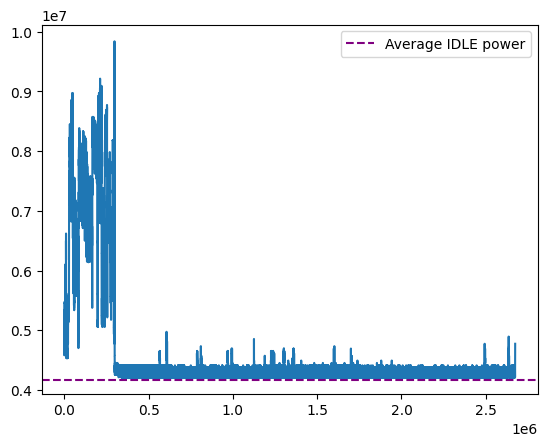

In [6]:
plt.plot([power for (timestamp, power) in vgg16_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [7]:
from utils import plot_inference_cycle_power

### Observations

There is a lot to unpack here from all the plots below.

Before that we will talk about `plot_inference_cycle_power` function, how it works and what it is doing.
- For a input inference cycle, the function finds the start index in the power logs data where `power_log_time >= first_layer_start_time`
- We iterate this loop until `power_log_time <= last_layer_end_time + 1 (sec)`. The index where loop finishes includes the time taken for the inference (start of first layer to end of last layer) and the delay of 1 second.
- Similarly, we find a power index corresponding to end time of last layer.

We have 3 indexes in power data for a given inference cycle
1. When the first layer for the network started
2. When the last layer for the network ended
3. When the delay of 1 second ended after the inference

Using these 3 values, we plot a line plot showing these 3 points as vertical lines.

#### Result

Let's take a look at **first iteration**,
1. The start and end vertical lines for the inference are so close to each other.
2. The power when inference started and ended was `9600000.0`. **Highest value observed so far**.
3. Then there is a delay of 1 second and power starts to decrease gradually.
4. The power at the end of 1 second delay was `4735104.0`

**Second iteration**
1. Similarly, the start and end vertical lines are close not overlapping (significant latency compared to other models).
2. The power seems to dissipating continuning the same trend from the first iteration.
3. The power at the start of inference was `4735104.0` and at the end of inference it decreased to `4895616.0`.
4. The power at the end of 1 second delay was `4293696.0`.


For rest of the iterations, the pattern looks like a downward step function where

- The power at inference start is a value greater than power consumed at IDLE state.
- The power at inference end is a value greater than power at inference start.
- The power at delay end is a value kess than both inference start and inference end `4213440.0`, the same power consumed for resnet18 and resnet34 models.


> **VGG16 model follows the same power profile pattern to that of Resnet34 and Alexnet models.**

> **The downward step function involves more steps compared to Resnet34 and Alexnet models.**


2025-01-17 11:29:24.351864 -> 2025-01-17 11:29:24.360605
2025-01-17 11:29:25.360605
Time taken by inference cycle 0: 0:00:00.008741
Iteration: 0, Power index: 297959 -> 297967
298753


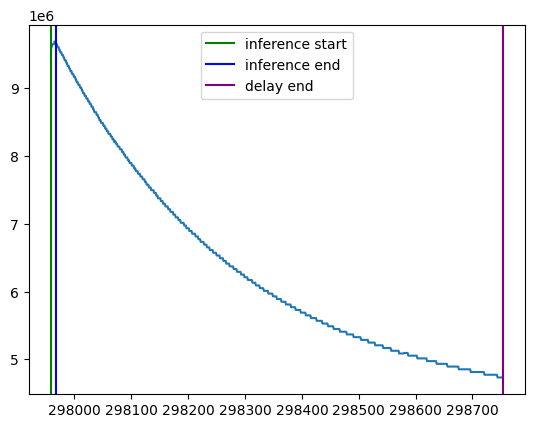

Power values:
Inference start: 9600000.0
Inference end: 9680000.0
Delay end: 4735104.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:25.363435 -> 2025-01-17 11:29:25.372039
2025-01-17 11:29:26.372039
Time taken by inference cycle 1: 0:00:00.008604
Iteration: 1, Power index: 298754 -> 298762
299547


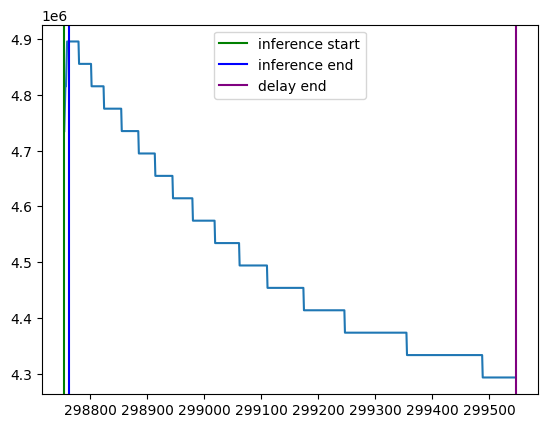

Power values:
Inference start: 4735104.0
Inference end: 4895616.0
Delay end: 4293696.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:26.374754 -> 2025-01-17 11:29:26.383293
2025-01-17 11:29:27.383293
Time taken by inference cycle 2: 0:00:00.008539
Iteration: 2, Power index: 299548 -> 299556
300342


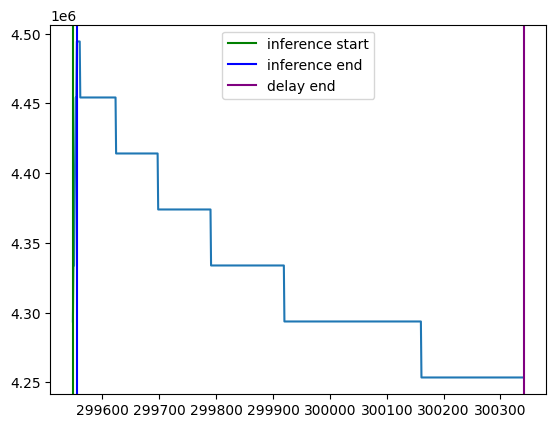

Power values:
Inference start: 4293696.0
Inference end: 4494336.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:27.385808 -> 2025-01-17 11:29:27.394425
2025-01-17 11:29:28.394425
Time taken by inference cycle 3: 0:00:00.008617
Iteration: 3, Power index: 300343 -> 300351
301136


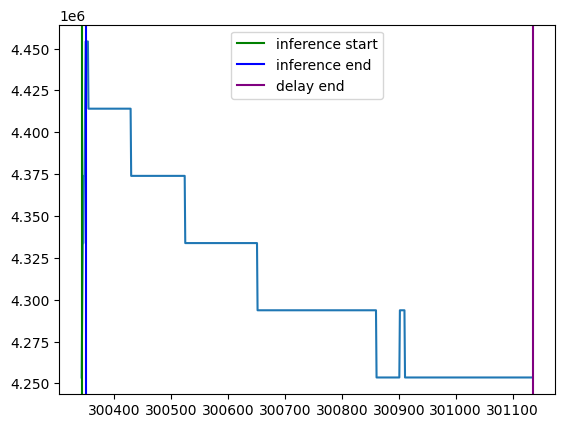

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:28.396880 -> 2025-01-17 11:29:28.405495
2025-01-17 11:29:29.405495
Time taken by inference cycle 4: 0:00:00.008615
Iteration: 4, Power index: 301137 -> 301145
301931


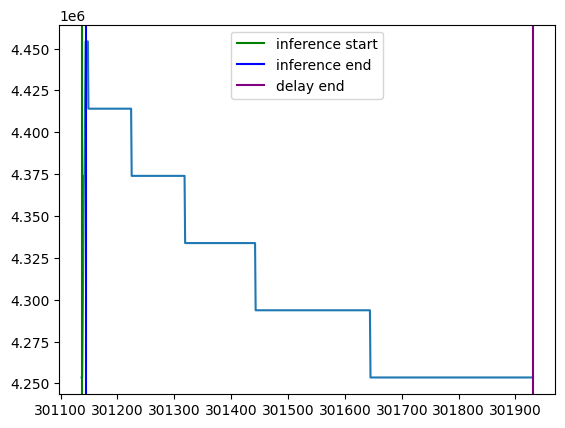

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:29.407936 -> 2025-01-17 11:29:29.416560
2025-01-17 11:29:30.416560
Time taken by inference cycle 5: 0:00:00.008624
Iteration: 5, Power index: 301932 -> 301939
302725


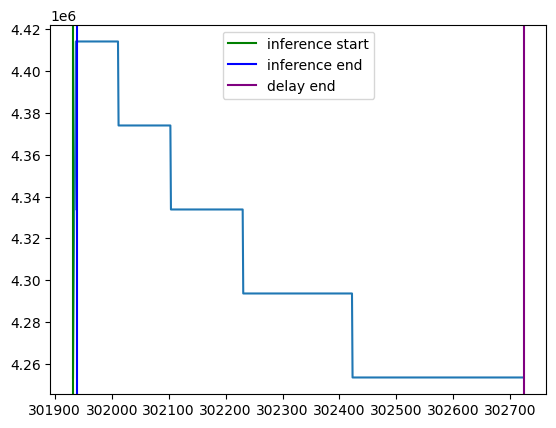

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:30.419020 -> 2025-01-17 11:29:30.427647
2025-01-17 11:29:31.427647
Time taken by inference cycle 6: 0:00:00.008627
Iteration: 6, Power index: 302726 -> 302734
303518


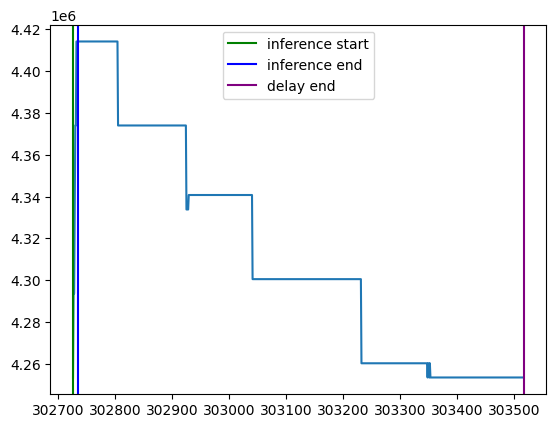

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:31.430158 -> 2025-01-17 11:29:31.438782
2025-01-17 11:29:32.438782
Time taken by inference cycle 7: 0:00:00.008624
Iteration: 7, Power index: 303519 -> 303527
304313


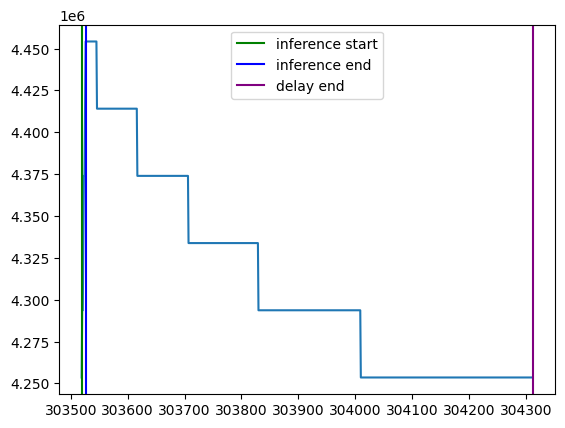

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:32.441195 -> 2025-01-17 11:29:32.449823
2025-01-17 11:29:33.449823
Time taken by inference cycle 8: 0:00:00.008628
Iteration: 8, Power index: 304314 -> 304321
305107


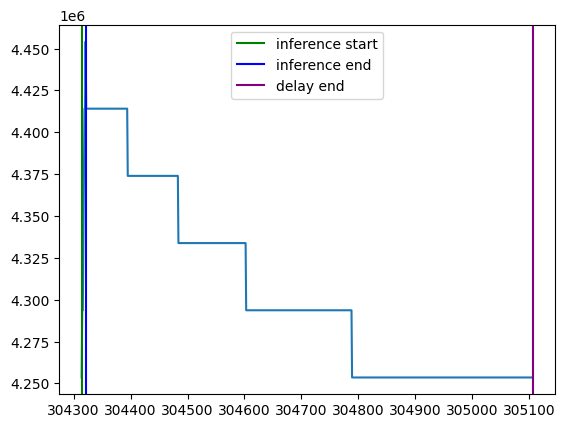

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:33.452251 -> 2025-01-17 11:29:33.460878
2025-01-17 11:29:34.460878
Time taken by inference cycle 9: 0:00:00.008627
Iteration: 9, Power index: 305108 -> 305116
305901


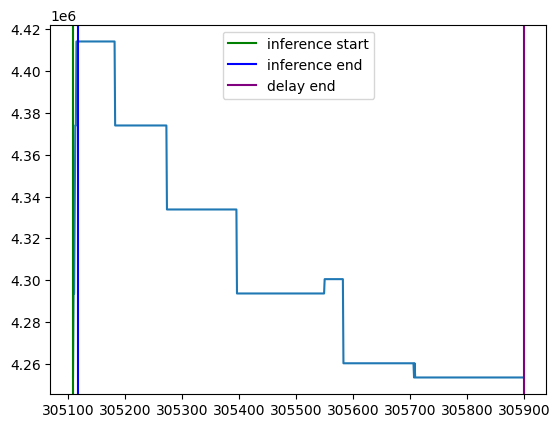

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:34.463321 -> 2025-01-17 11:29:34.471944
2025-01-17 11:29:35.471944
Time taken by inference cycle 10: 0:00:00.008623
Iteration: 10, Power index: 305902 -> 305910
306695


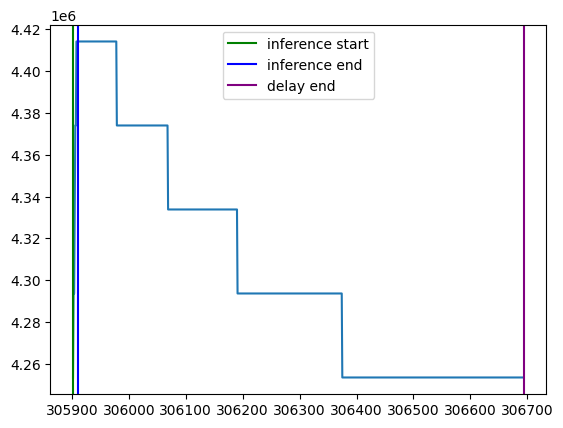

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:35.474462 -> 2025-01-17 11:29:35.483078
2025-01-17 11:29:36.483078
Time taken by inference cycle 11: 0:00:00.008616
Iteration: 11, Power index: 306696 -> 306704
307490


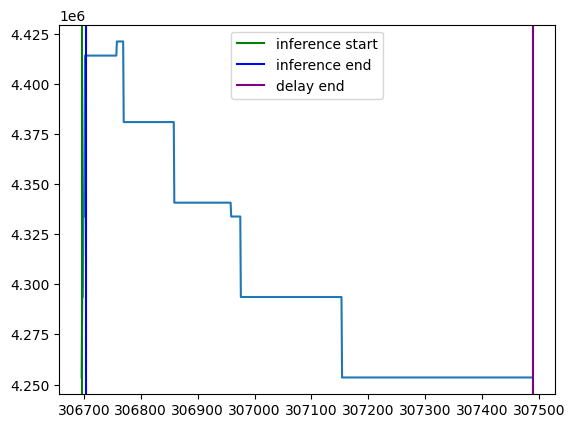

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:36.485566 -> 2025-01-17 11:29:36.494309
2025-01-17 11:29:37.494309
Time taken by inference cycle 12: 0:00:00.008743
Iteration: 12, Power index: 307491 -> 307499
308285


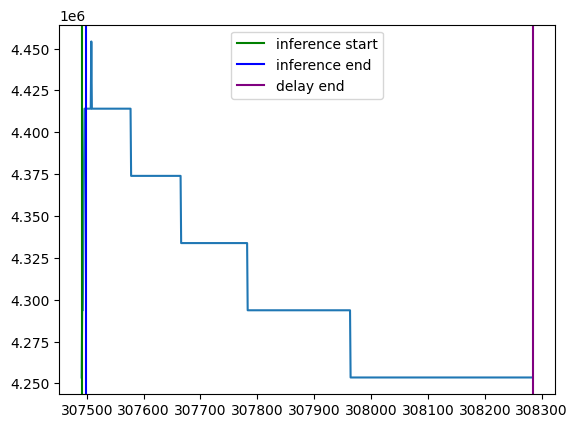

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:37.496847 -> 2025-01-17 11:29:37.505444
2025-01-17 11:29:38.505444
Time taken by inference cycle 13: 0:00:00.008597
Iteration: 13, Power index: 308286 -> 308293
309080


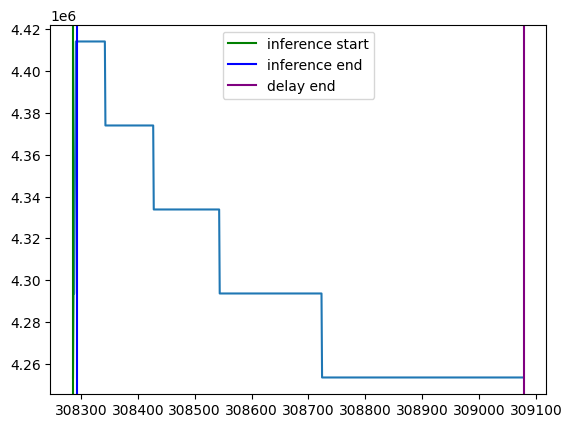

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:29:38.507994 -> 2025-01-17 11:29:38.516591
2025-01-17 11:29:39.516591
Time taken by inference cycle 14: 0:00:00.008597
Iteration: 14, Power index: 309081 -> 309088
309874


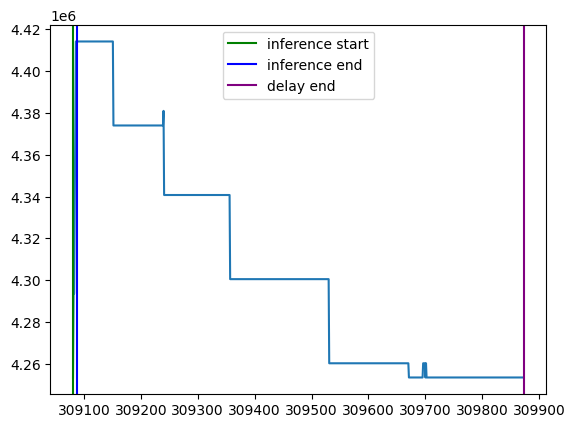

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------


In [8]:
for i in range(15):
    plot_inference_cycle_power(i, vgg16_power_data, vgg16_latency_data, DELAY)

2025-01-17 11:31:05.467992 -> 2025-01-17 11:31:05.476580
2025-01-17 11:31:06.476580
Time taken by inference cycle 100: 0:00:00.008588
Iteration: 100, Power index: 377438 -> 377446
378232


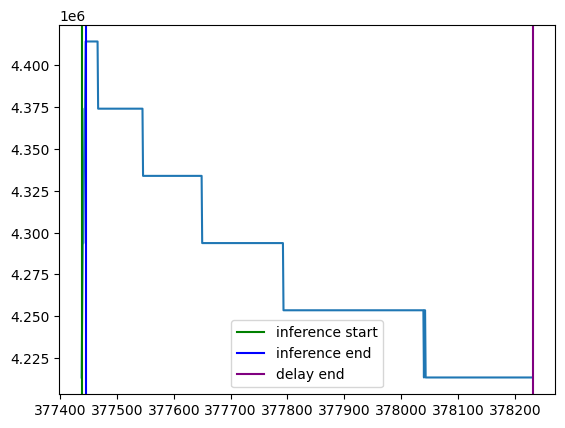

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:06.479244 -> 2025-01-17 11:31:06.487855
2025-01-17 11:31:07.487855
Time taken by inference cycle 101: 0:00:00.008611
Iteration: 101, Power index: 378233 -> 378241
379026


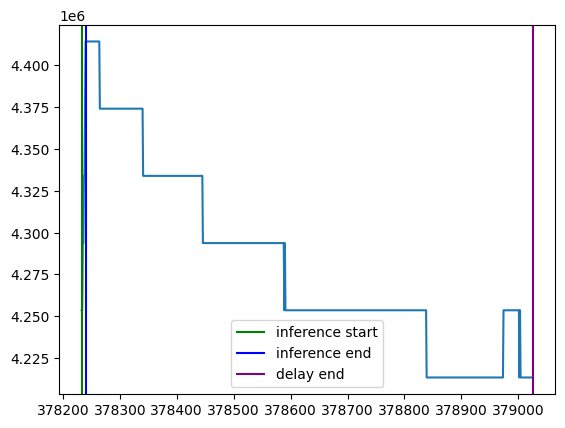

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:07.490883 -> 2025-01-17 11:31:07.499401
2025-01-17 11:31:08.499401
Time taken by inference cycle 102: 0:00:00.008518
Iteration: 102, Power index: 379028 -> 379035
379822


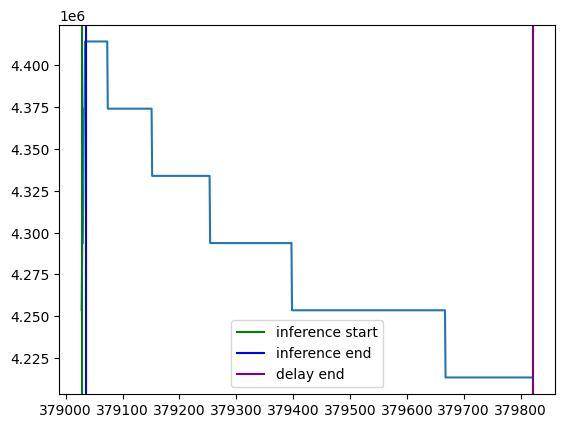

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:08.502114 -> 2025-01-17 11:31:08.510740
2025-01-17 11:31:09.510740
Time taken by inference cycle 103: 0:00:00.008626
Iteration: 103, Power index: 379823 -> 379830
380617


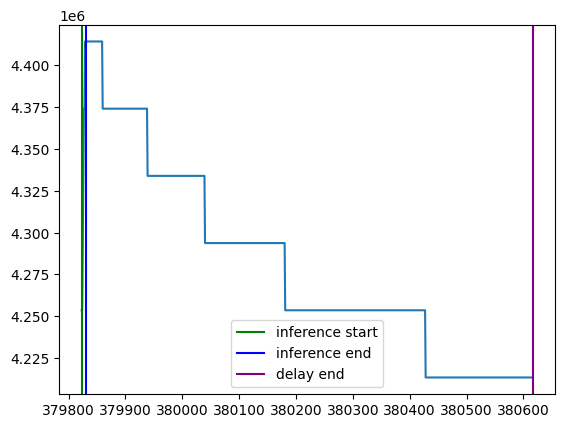

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:09.513386 -> 2025-01-17 11:31:09.521975
2025-01-17 11:31:10.521975
Time taken by inference cycle 104: 0:00:00.008589
Iteration: 104, Power index: 380618 -> 380625
381412


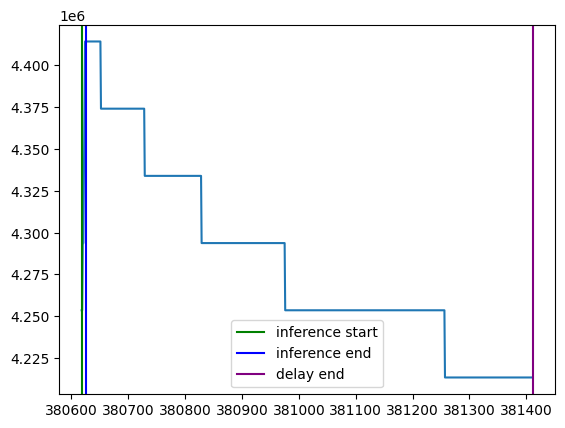

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:10.524085 -> 2025-01-17 11:31:10.532669
2025-01-17 11:31:11.532669
Time taken by inference cycle 105: 0:00:00.008584
Iteration: 105, Power index: 381412 -> 381420
382206


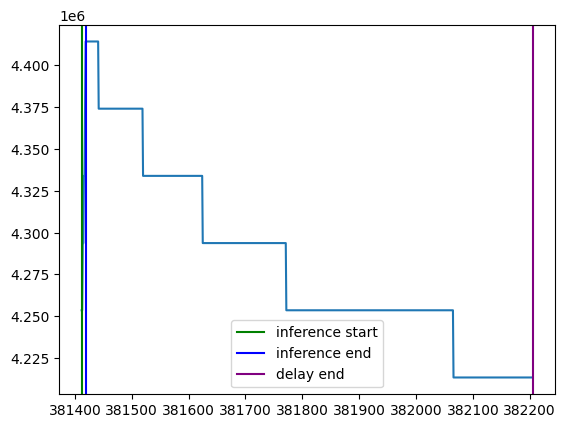

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:11.535348 -> 2025-01-17 11:31:11.543937
2025-01-17 11:31:12.543937
Time taken by inference cycle 106: 0:00:00.008589
Iteration: 106, Power index: 382207 -> 382215
383001


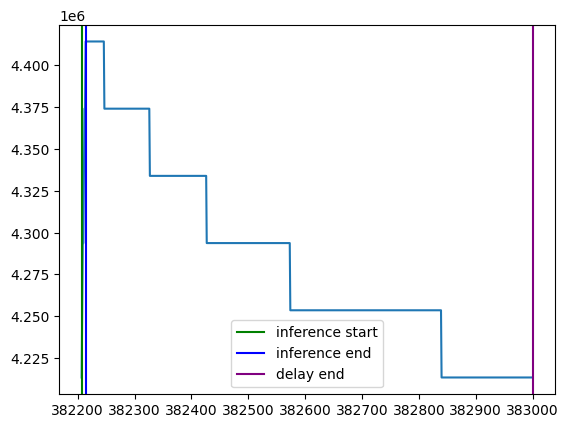

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:12.546638 -> 2025-01-17 11:31:12.555194
2025-01-17 11:31:13.555194
Time taken by inference cycle 107: 0:00:00.008556
Iteration: 107, Power index: 383002 -> 383010
383796


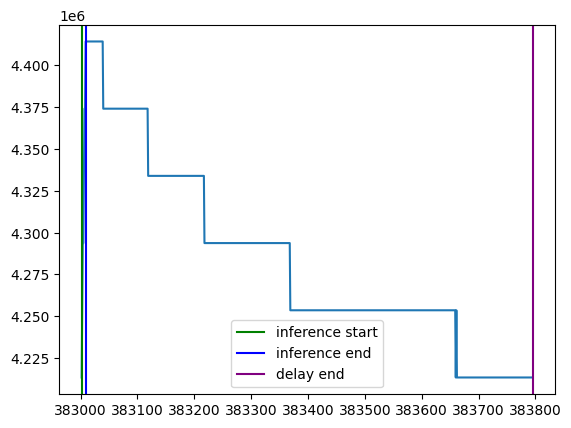

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:13.557710 -> 2025-01-17 11:31:13.566322
2025-01-17 11:31:14.566322
Time taken by inference cycle 108: 0:00:00.008612
Iteration: 108, Power index: 383797 -> 383805
384591


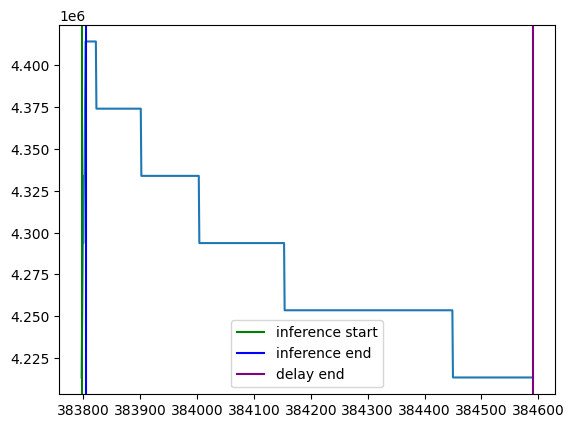

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:14.568890 -> 2025-01-17 11:31:14.577514
2025-01-17 11:31:15.577514
Time taken by inference cycle 109: 0:00:00.008624
Iteration: 109, Power index: 384592 -> 384600
385385


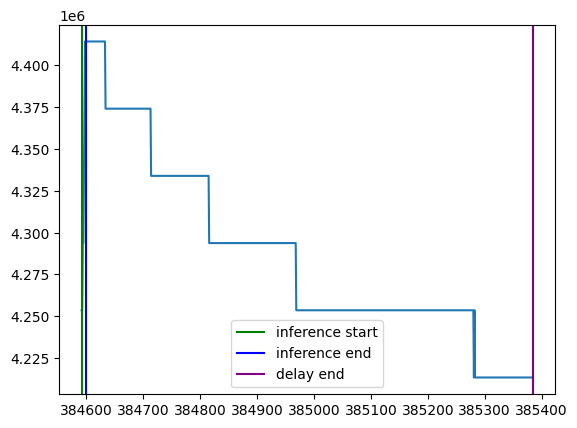

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:15.579972 -> 2025-01-17 11:31:15.588588
2025-01-17 11:31:16.588588
Time taken by inference cycle 110: 0:00:00.008616
Iteration: 110, Power index: 385386 -> 385394
386180


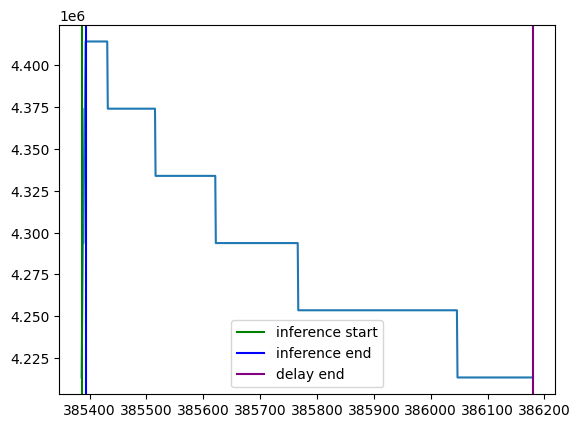

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:16.591240 -> 2025-01-17 11:31:16.599849
2025-01-17 11:31:17.599849
Time taken by inference cycle 111: 0:00:00.008609
Iteration: 111, Power index: 386181 -> 386189
386975


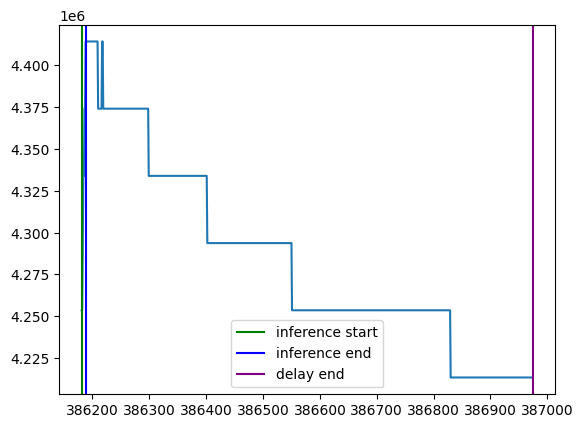

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:17.602444 -> 2025-01-17 11:31:17.611048
2025-01-17 11:31:18.611048
Time taken by inference cycle 112: 0:00:00.008604
Iteration: 112, Power index: 386976 -> 386983
387769


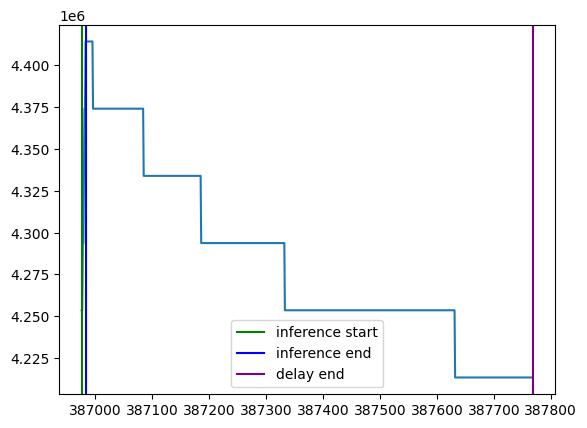

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:18.613634 -> 2025-01-17 11:31:18.622247
2025-01-17 11:31:19.622247
Time taken by inference cycle 113: 0:00:00.008613
Iteration: 113, Power index: 387770 -> 387778
388564


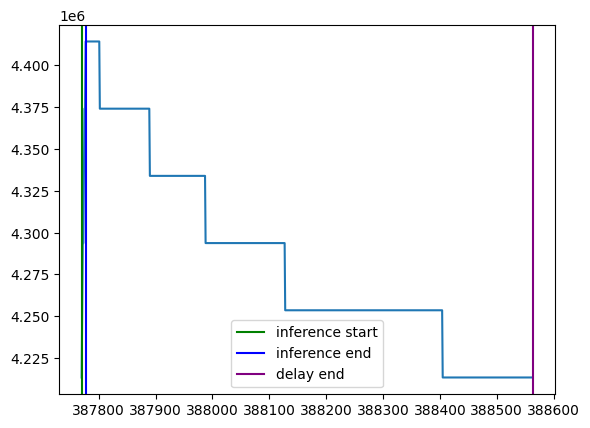

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:19.625000 -> 2025-01-17 11:31:19.633576
2025-01-17 11:31:20.633576
Time taken by inference cycle 114: 0:00:00.008576
Iteration: 114, Power index: 388565 -> 388572
389359


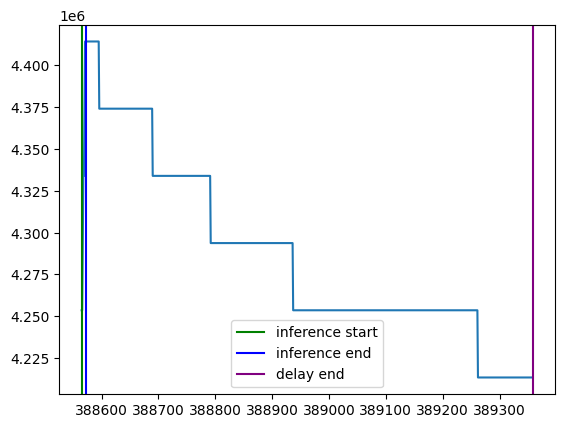

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:20.636112 -> 2025-01-17 11:31:20.644702
2025-01-17 11:31:21.644702
Time taken by inference cycle 115: 0:00:00.008590
Iteration: 115, Power index: 389360 -> 389367
390153


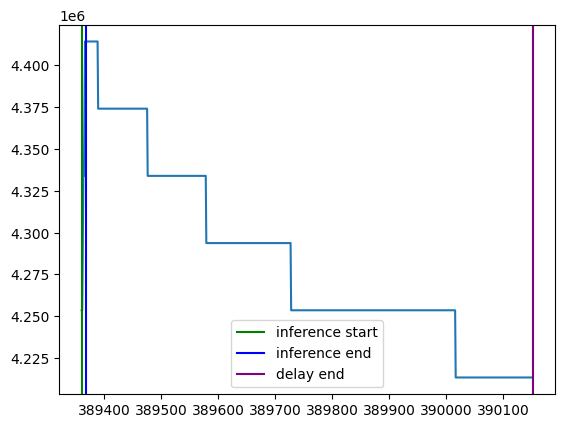

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:21.647397 -> 2025-01-17 11:31:21.655981
2025-01-17 11:31:22.655981
Time taken by inference cycle 116: 0:00:00.008584
Iteration: 116, Power index: 390154 -> 390162
390948


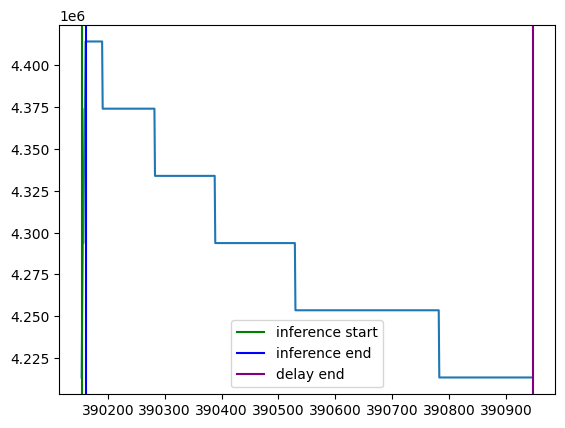

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:22.658648 -> 2025-01-17 11:31:22.667206
2025-01-17 11:31:23.667206
Time taken by inference cycle 117: 0:00:00.008558
Iteration: 117, Power index: 390949 -> 390956
391743


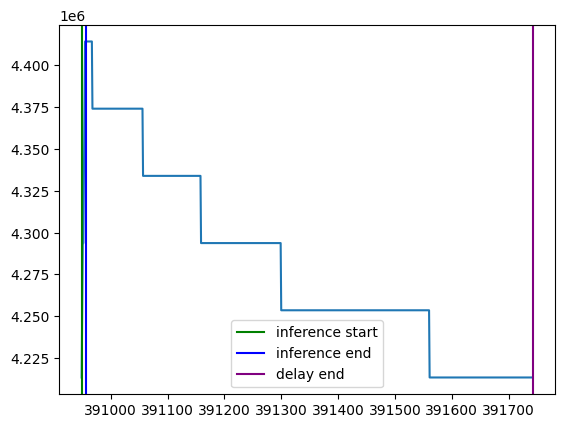

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:23.669837 -> 2025-01-17 11:31:23.678440
2025-01-17 11:31:24.678440
Time taken by inference cycle 118: 0:00:00.008603
Iteration: 118, Power index: 391744 -> 391751
392537


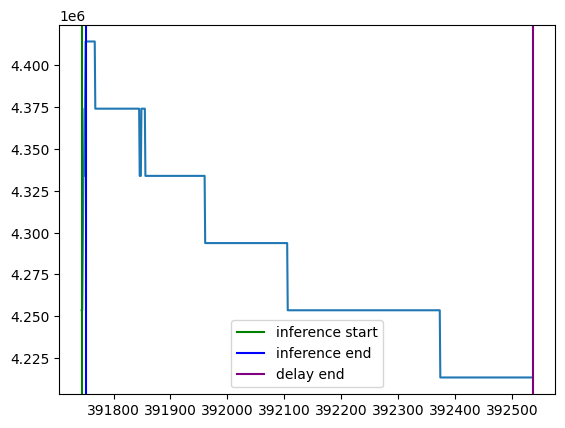

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:24.681086 -> 2025-01-17 11:31:24.689691
2025-01-17 11:31:25.689691
Time taken by inference cycle 119: 0:00:00.008605
Iteration: 119, Power index: 392538 -> 392546
393332


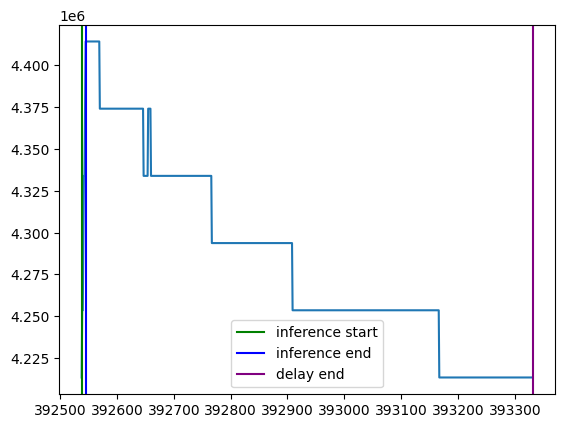

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:25.692310 -> 2025-01-17 11:31:25.700908
2025-01-17 11:31:26.700908
Time taken by inference cycle 120: 0:00:00.008598
Iteration: 120, Power index: 393333 -> 393341
394127


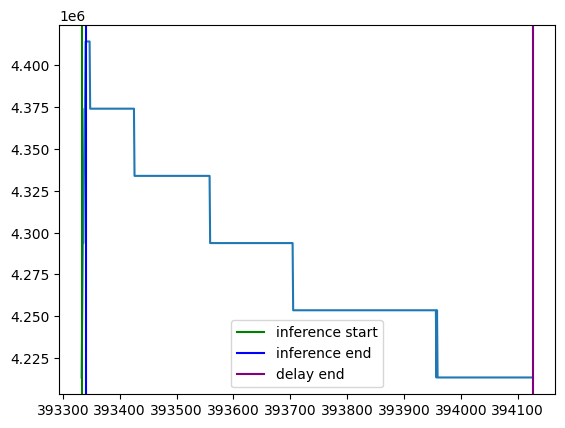

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:26.703733 -> 2025-01-17 11:31:26.712316
2025-01-17 11:31:27.712316
Time taken by inference cycle 121: 0:00:00.008583
Iteration: 121, Power index: 394128 -> 394136
394922


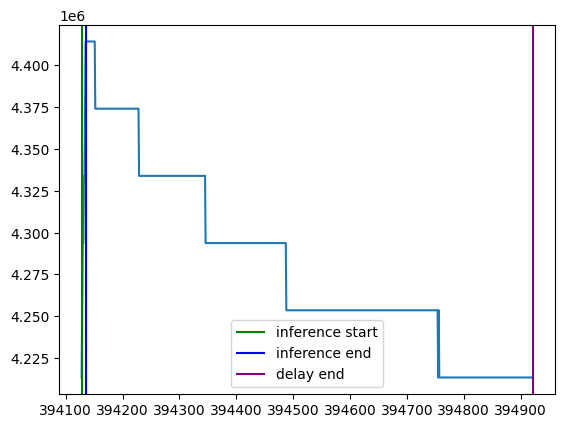

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:27.715074 -> 2025-01-17 11:31:27.723665
2025-01-17 11:31:28.723665
Time taken by inference cycle 122: 0:00:00.008591
Iteration: 122, Power index: 394923 -> 394931
395717


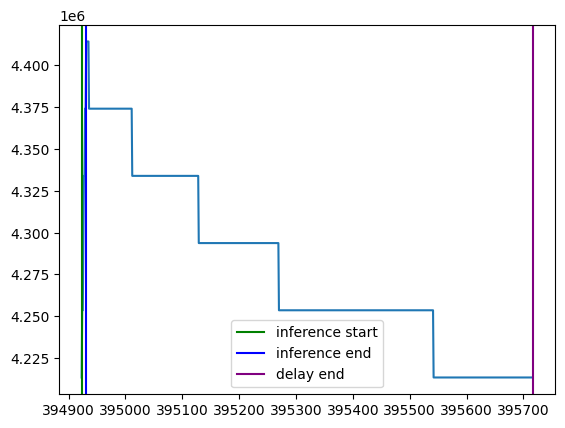

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:28.726410 -> 2025-01-17 11:31:28.735016
2025-01-17 11:31:29.735016
Time taken by inference cycle 123: 0:00:00.008606
Iteration: 123, Power index: 395718 -> 395726
396512


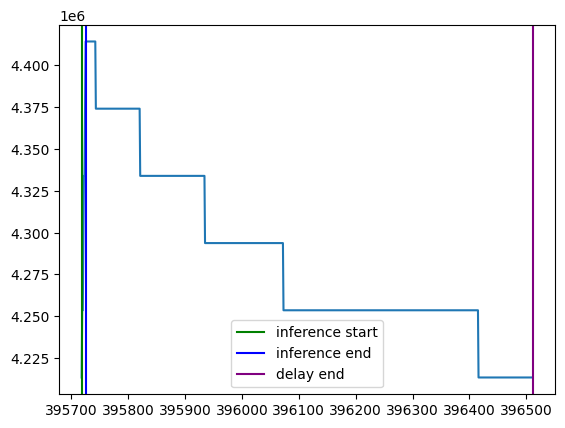

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:29.737987 -> 2025-01-17 11:31:29.746573
2025-01-17 11:31:30.746573
Time taken by inference cycle 124: 0:00:00.008586
Iteration: 124, Power index: 396513 -> 396521
397307


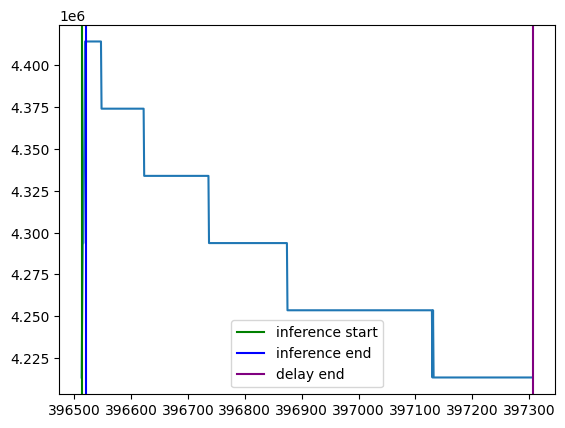

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:30.749417 -> 2025-01-17 11:31:30.758031
2025-01-17 11:31:31.758031
Time taken by inference cycle 125: 0:00:00.008614
Iteration: 125, Power index: 397309 -> 397316
398103


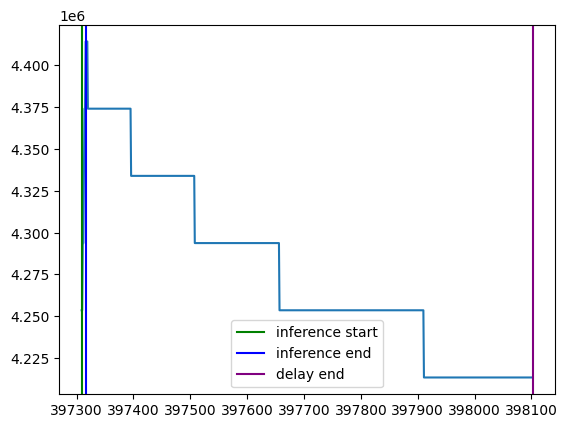

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:31.760195 -> 2025-01-17 11:31:31.768796
2025-01-17 11:31:32.768796
Time taken by inference cycle 126: 0:00:00.008601
Iteration: 126, Power index: 398104 -> 398111
398897


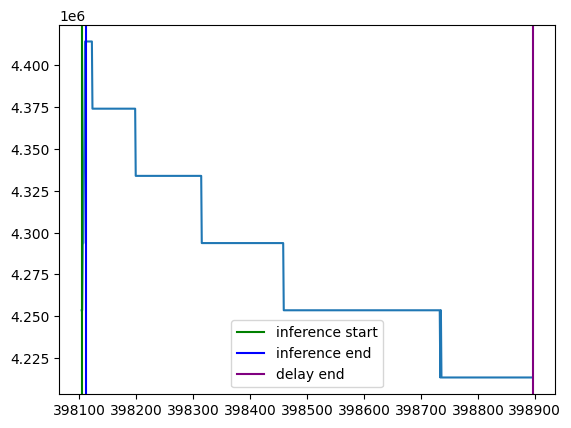

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:32.771572 -> 2025-01-17 11:31:32.780184
2025-01-17 11:31:33.780184
Time taken by inference cycle 127: 0:00:00.008612
Iteration: 127, Power index: 398899 -> 398906
399692


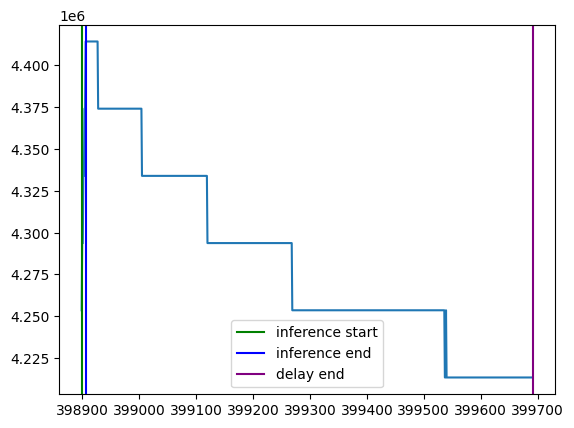

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:33.782960 -> 2025-01-17 11:31:33.791589
2025-01-17 11:31:34.791589
Time taken by inference cycle 128: 0:00:00.008629
Iteration: 128, Power index: 399693 -> 399701
400487


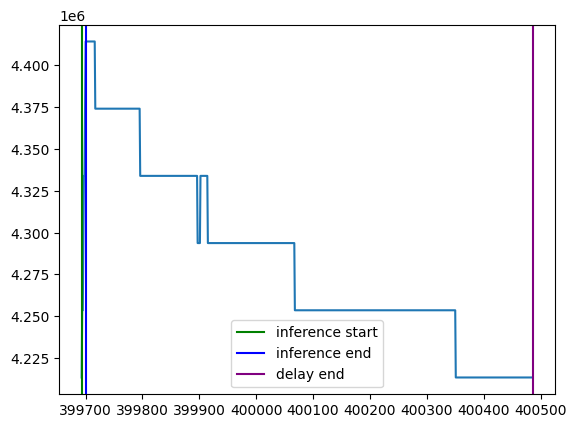

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:34.794324 -> 2025-01-17 11:31:34.802907
2025-01-17 11:31:35.802907
Time taken by inference cycle 129: 0:00:00.008583
Iteration: 129, Power index: 400488 -> 400495
401281


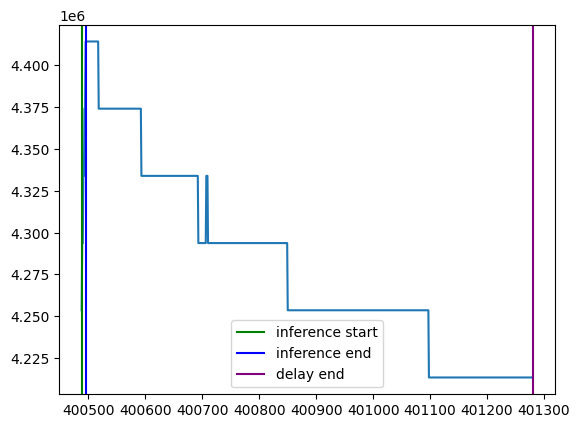

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:35.805643 -> 2025-01-17 11:31:35.814238
2025-01-17 11:31:36.814238
Time taken by inference cycle 130: 0:00:00.008595
Iteration: 130, Power index: 401282 -> 401290
402076


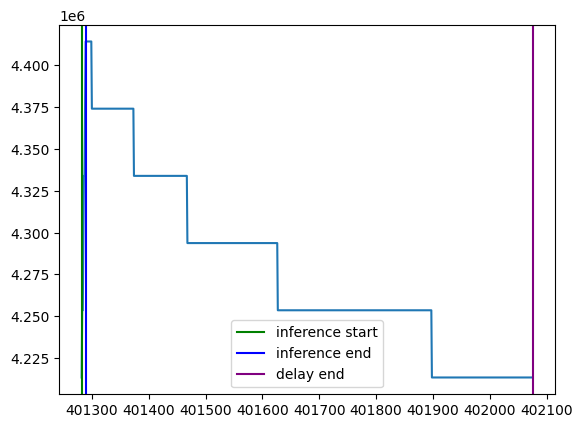

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:36.816946 -> 2025-01-17 11:31:36.825549
2025-01-17 11:31:37.825549
Time taken by inference cycle 131: 0:00:00.008603
Iteration: 131, Power index: 402077 -> 402085
402871


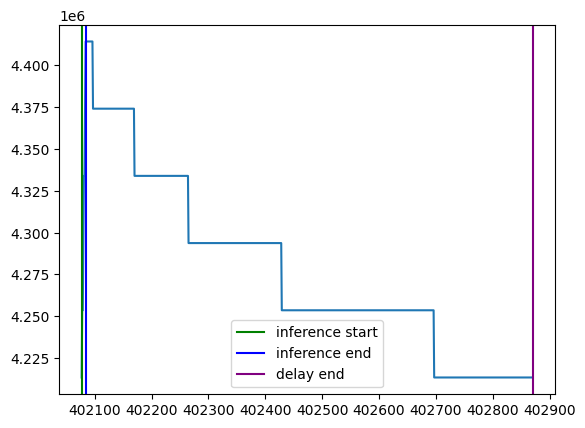

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:37.828148 -> 2025-01-17 11:31:37.836747
2025-01-17 11:31:38.836747
Time taken by inference cycle 132: 0:00:00.008599
Iteration: 132, Power index: 402872 -> 402880
403666


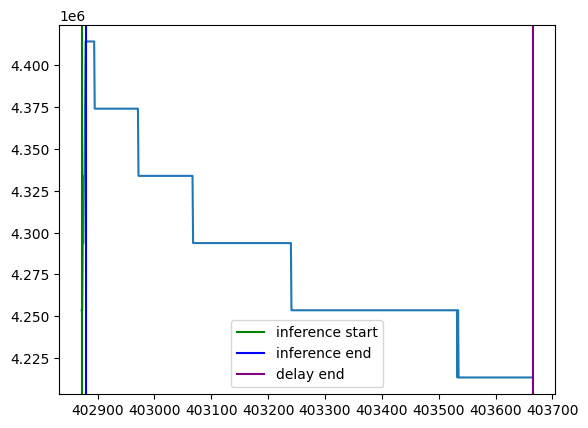

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:38.839524 -> 2025-01-17 11:31:38.848120
2025-01-17 11:31:39.848120
Time taken by inference cycle 133: 0:00:00.008596
Iteration: 133, Power index: 403667 -> 403675
404461


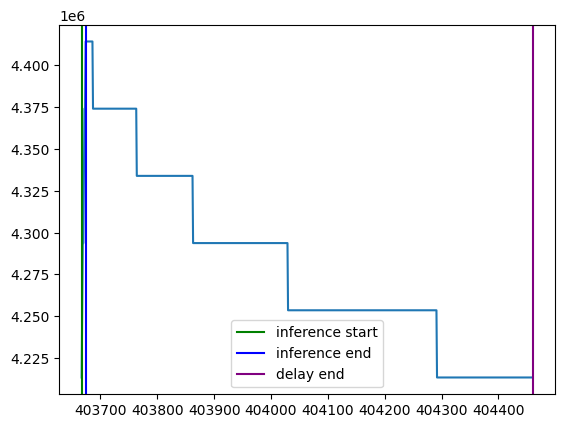

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:39.850884 -> 2025-01-17 11:31:39.859422
2025-01-17 11:31:40.859422
Time taken by inference cycle 134: 0:00:00.008538
Iteration: 134, Power index: 404462 -> 404470
405256


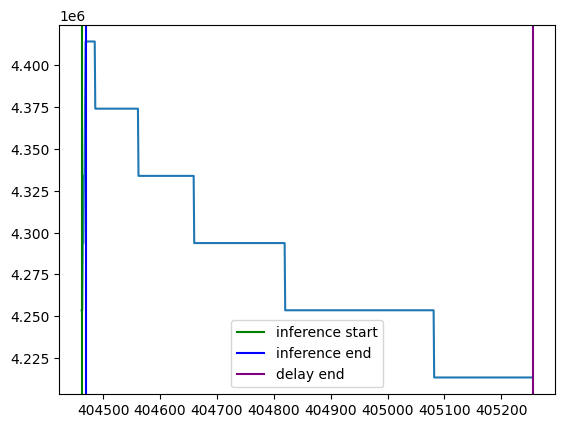

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:40.862149 -> 2025-01-17 11:31:40.870752
2025-01-17 11:31:41.870752
Time taken by inference cycle 135: 0:00:00.008603
Iteration: 135, Power index: 405257 -> 405264
406050


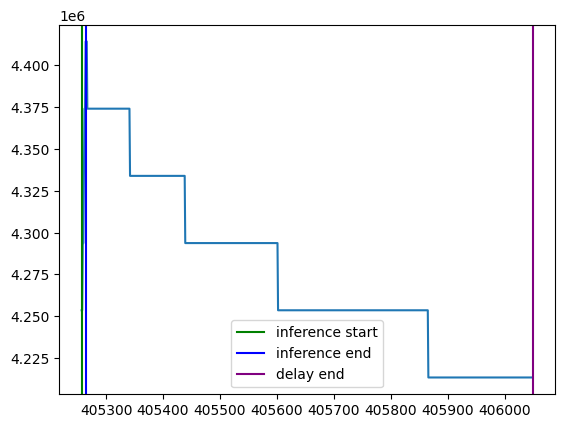

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:41.873469 -> 2025-01-17 11:31:41.882086
2025-01-17 11:31:42.882086
Time taken by inference cycle 136: 0:00:00.008617
Iteration: 136, Power index: 406051 -> 406059
406844


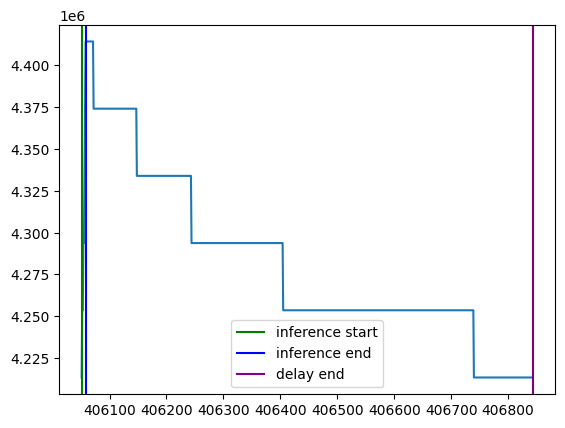

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:42.884418 -> 2025-01-17 11:31:42.892987
2025-01-17 11:31:43.892987
Time taken by inference cycle 137: 0:00:00.008569
Iteration: 137, Power index: 406845 -> 406853
407639


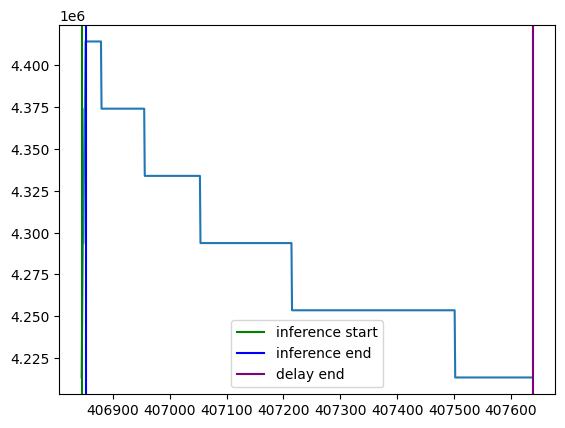

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:43.895818 -> 2025-01-17 11:31:43.904414
2025-01-17 11:31:44.904414
Time taken by inference cycle 138: 0:00:00.008596
Iteration: 138, Power index: 407640 -> 407648
408433


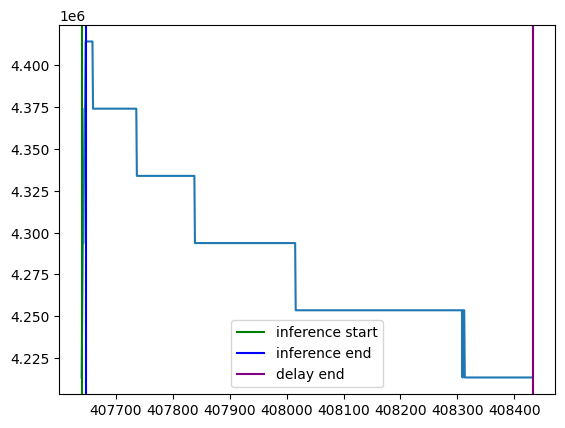

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:44.907237 -> 2025-01-17 11:31:44.915836
2025-01-17 11:31:45.915836
Time taken by inference cycle 139: 0:00:00.008599
Iteration: 139, Power index: 408434 -> 408441
409228


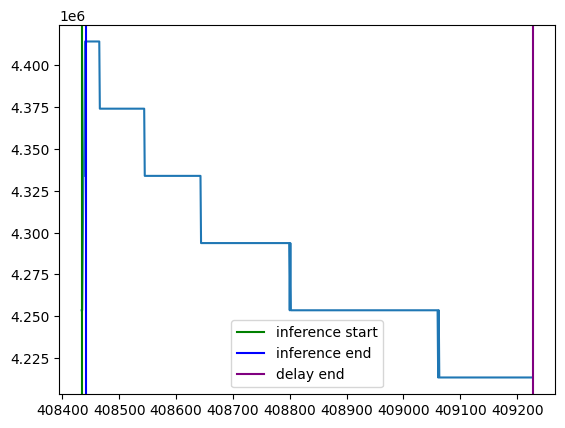

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:45.918627 -> 2025-01-17 11:31:45.927200
2025-01-17 11:31:46.927200
Time taken by inference cycle 140: 0:00:00.008573
Iteration: 140, Power index: 409229 -> 409236
410022


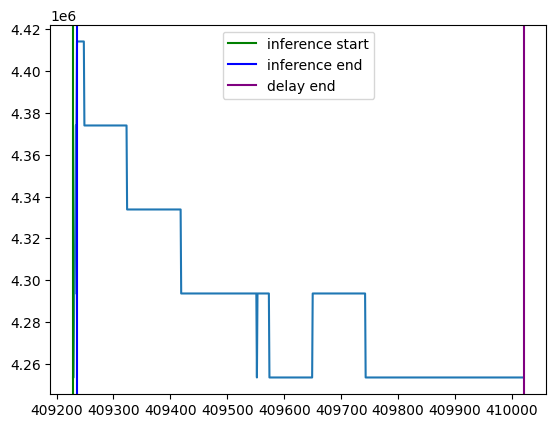

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:46.930495 -> 2025-01-17 11:31:46.939048
2025-01-17 11:31:47.939048
Time taken by inference cycle 141: 0:00:00.008553
Iteration: 141, Power index: 410023 -> 410031
410818


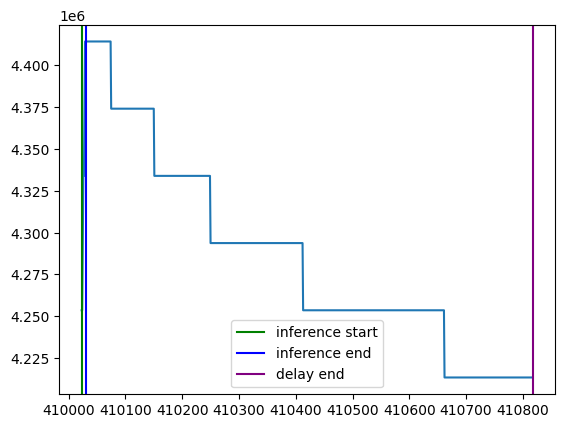

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:47.941872 -> 2025-01-17 11:31:47.950471
2025-01-17 11:31:48.950471
Time taken by inference cycle 142: 0:00:00.008599
Iteration: 142, Power index: 410819 -> 410827
411613


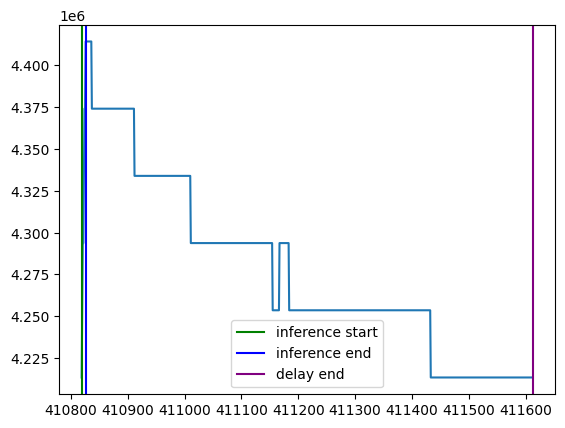

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:48.953265 -> 2025-01-17 11:31:48.961868
2025-01-17 11:31:49.961868
Time taken by inference cycle 143: 0:00:00.008603
Iteration: 143, Power index: 411615 -> 411622
412409


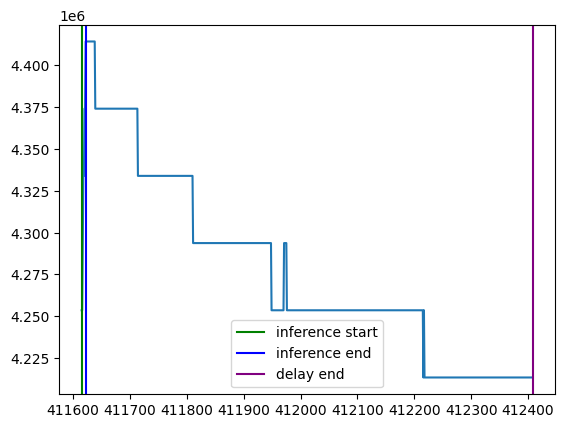

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:49.964315 -> 2025-01-17 11:31:49.972903
2025-01-17 11:31:50.972903
Time taken by inference cycle 144: 0:00:00.008588
Iteration: 144, Power index: 412410 -> 412418
413204


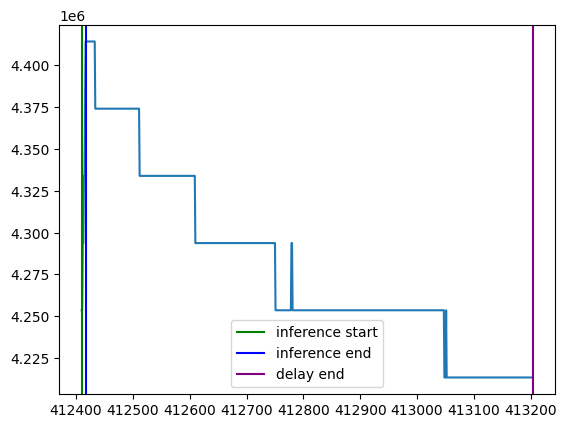

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:50.975743 -> 2025-01-17 11:31:50.984337
2025-01-17 11:31:51.984337
Time taken by inference cycle 145: 0:00:00.008594
Iteration: 145, Power index: 413206 -> 413213
414000


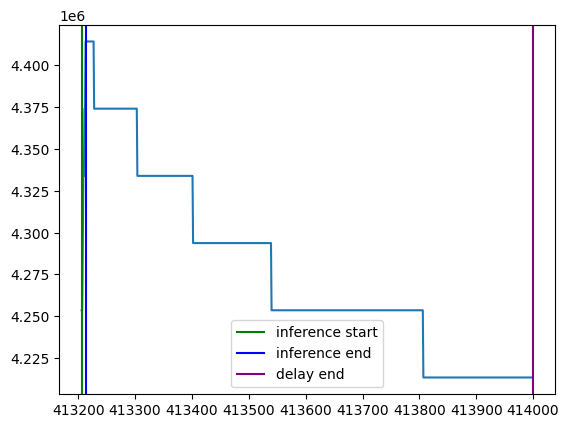

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:51.987154 -> 2025-01-17 11:31:51.995747
2025-01-17 11:31:52.995747
Time taken by inference cycle 146: 0:00:00.008593
Iteration: 146, Power index: 414001 -> 414009
414795


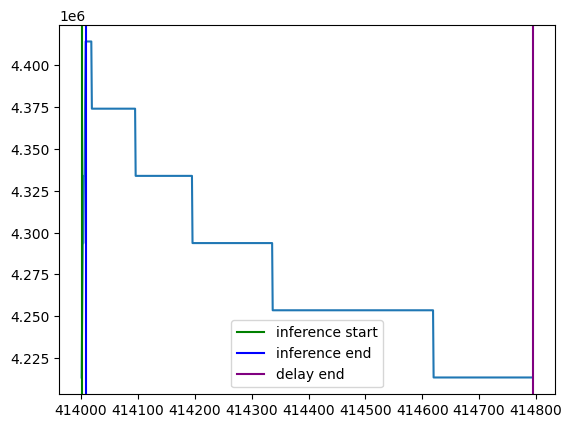

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:52.998560 -> 2025-01-17 11:31:53.007130
2025-01-17 11:31:54.007130
Time taken by inference cycle 147: 0:00:00.008570
Iteration: 147, Power index: 414796 -> 414804
415590


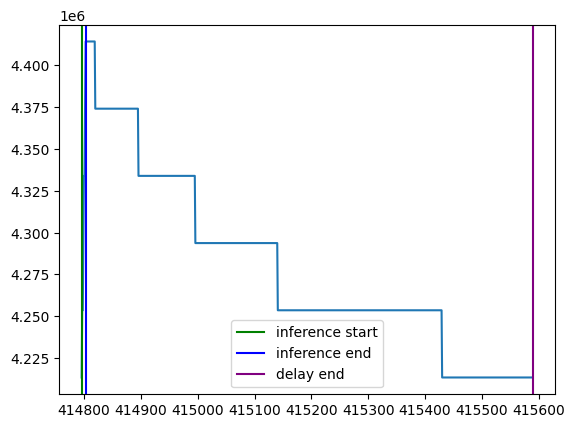

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:54.009940 -> 2025-01-17 11:31:54.018545
2025-01-17 11:31:55.018545
Time taken by inference cycle 148: 0:00:00.008605
Iteration: 148, Power index: 415592 -> 415599
416386


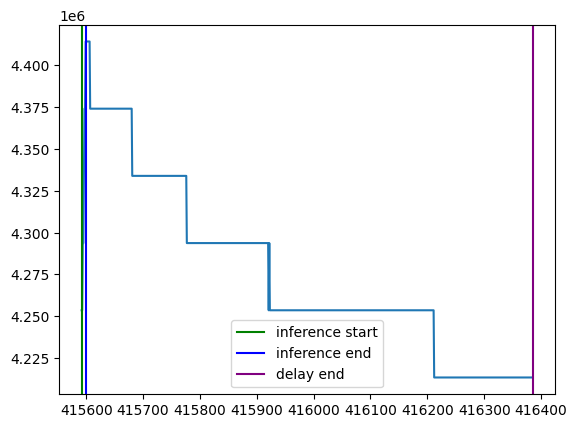

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 11:31:55.021413 -> 2025-01-17 11:31:55.030018
2025-01-17 11:31:56.030018
Time taken by inference cycle 149: 0:00:00.008605
Iteration: 149, Power index: 416387 -> 416395
417181


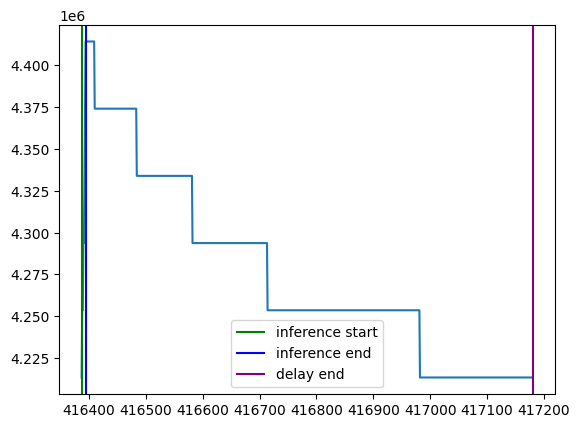

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [9]:
for i in range(100, 150):
    plot_inference_cycle_power(i, vgg16_power_data, vgg16_latency_data, DELAY)

## VGG19

In this section, we will analyse the power consumption of VGG19 model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.

In [10]:
model_name = 'vgg19'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
vgg19_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
vgg19_latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:01<00:00, 35.40it/s]


In [11]:
print(f"Number of power entries for {model_name}: {len(vgg19_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(vgg19_latency_data[0])}")
layer = list(data.keys())[0]
print(f"Number of latency entries for each layer: {len(vgg19_latency_data)}")

Number of power entries for vgg19: 2704068
Number of TensorRT layers in vgg19: 40
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.3 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.3.

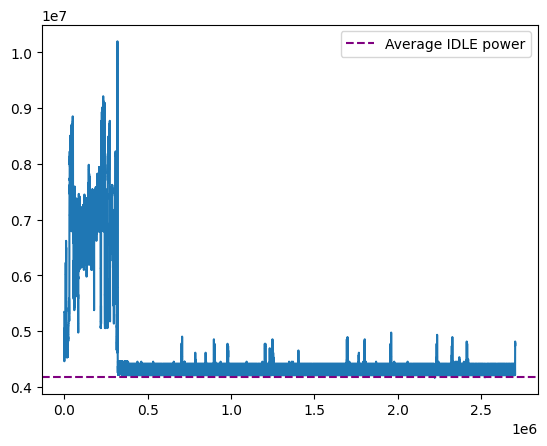

In [12]:
plt.plot([power for (timestamp, power) in vgg19_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [13]:
from utils import plot_inference_cycle_power

### Observations

Similar methodology as VGG16 is used to get index values in the power log for each inference cycle and layer.

#### Result

Let's take a look at **first iteration**,
1. The start and end vertical lines for the inference are so close to each other.
2. The power when inference started and ended was `9600000.0`. **Highest value observed so far similar to VGG16**.
3. Then there is a delay of 1 second and power starts to decrease gradually.
4. The power at the end of 1 second delay was `4735104.0`

**Second iteration**
1. Similarly, the start and end vertical lines are close not overlapping (significant latency compared to other models).
2. The power seems to dissipating continuning the same trend from the first iteration.
3. The power at the start of inference was `4735104.0` and at the end of inference it decreased to `4895616.0`.
4. The power at the end of 1 second delay was `4293696.0`.


For rest of the iterations, the pattern looks like a downward step function where

- The power at inference start is a value greater than power consumed at IDLE state.
- The power at inference end is a value greater than power at inference start.
- The power at delay end is a value kess than both inference start and inference end `4213440.0`, the same power consumed for resnet18 and resnet34 models.


> **VGG19 model follows the similar power profile to that of VGG16. Only 3 layers are increased between VGG16 and VGG19**

> **The downward step function involves more steps compared to Resnet34 and Alexnet models.**


2025-01-17 12:27:15.181171 -> 2025-01-17 12:27:15.191196
2025-01-17 12:27:16.191196
Time taken by inference cycle 0: 0:00:00.010025
Iteration: 0, Power index: 319000 -> 319009
319795


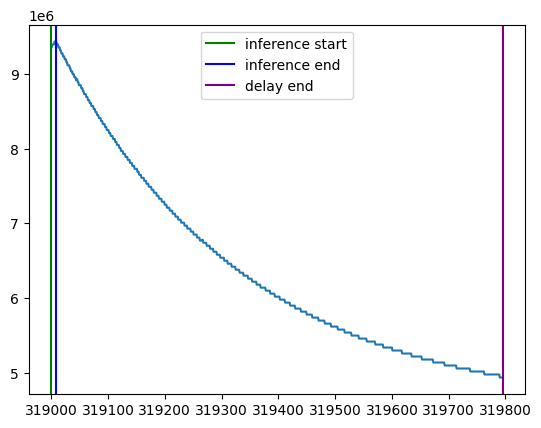

Power values:
Inference start: 9360000.0
Inference end: 9440000.0
Delay end: 4935744.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:16.194074 -> 2025-01-17 12:27:16.204009
2025-01-17 12:27:17.204009
Time taken by inference cycle 1: 0:00:00.009935
Iteration: 1, Power index: 319796 -> 319805
320590


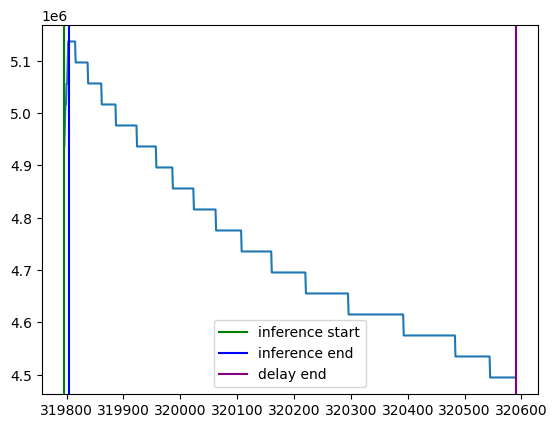

Power values:
Inference start: 4935744.0
Inference end: 5136384.0
Delay end: 4494336.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:17.206997 -> 2025-01-17 12:27:17.216834
2025-01-17 12:27:18.216834
Time taken by inference cycle 2: 0:00:00.009837
Iteration: 2, Power index: 320591 -> 320600
321385


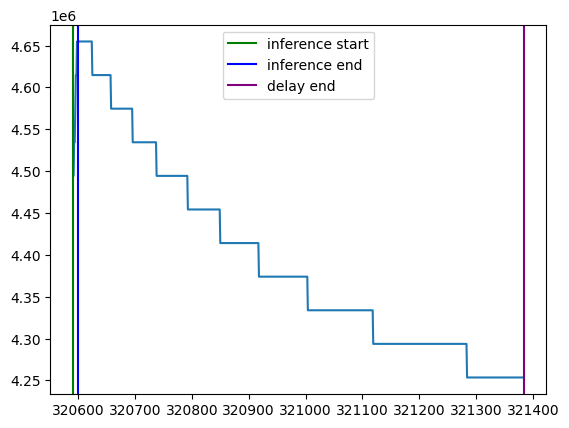

Power values:
Inference start: 4494336.0
Inference end: 4654848.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:18.219470 -> 2025-01-17 12:27:18.229339
2025-01-17 12:27:19.229339
Time taken by inference cycle 3: 0:00:00.009869
Iteration: 3, Power index: 321386 -> 321395
322181


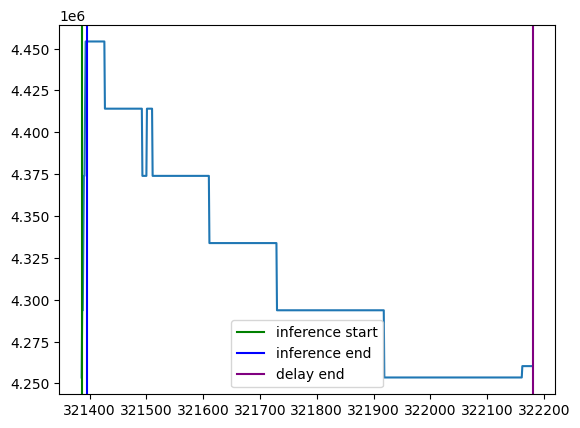

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4260352.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:19.231931 -> 2025-01-17 12:27:19.241787
2025-01-17 12:27:20.241787
Time taken by inference cycle 4: 0:00:00.009856
Iteration: 4, Power index: 322182 -> 322191
322976


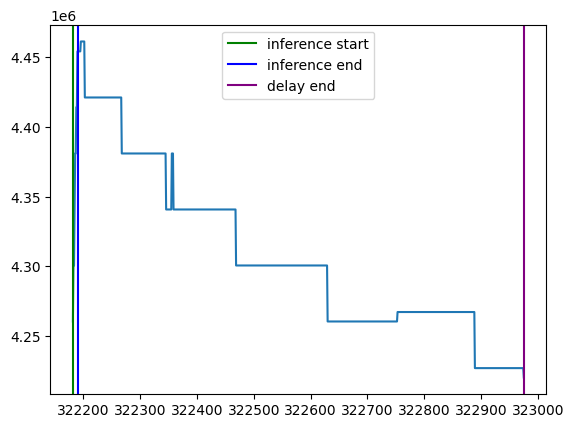

Power values:
Inference start: 4260352.0
Inference end: 4454208.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:20.244321 -> 2025-01-17 12:27:20.254195
2025-01-17 12:27:21.254195
Time taken by inference cycle 5: 0:00:00.009874
Iteration: 5, Power index: 322977 -> 322986
323772


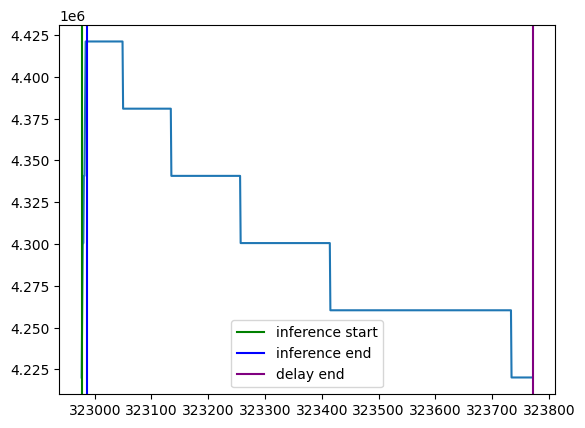

Power values:
Inference start: 4220160.0
Inference end: 4421120.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:21.256803 -> 2025-01-17 12:27:21.266667
2025-01-17 12:27:22.266667
Time taken by inference cycle 6: 0:00:00.009864
Iteration: 6, Power index: 323773 -> 323782
324568


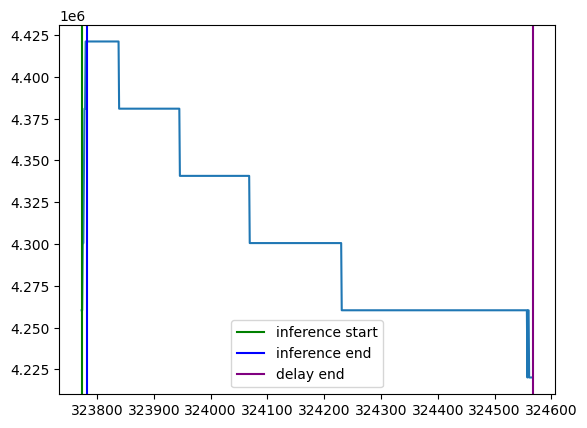

Power values:
Inference start: 4260352.0
Inference end: 4421120.0
Delay end: 4260352.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:22.269246 -> 2025-01-17 12:27:22.279102
2025-01-17 12:27:23.279102
Time taken by inference cycle 7: 0:00:00.009856
Iteration: 7, Power index: 324569 -> 324578
325364


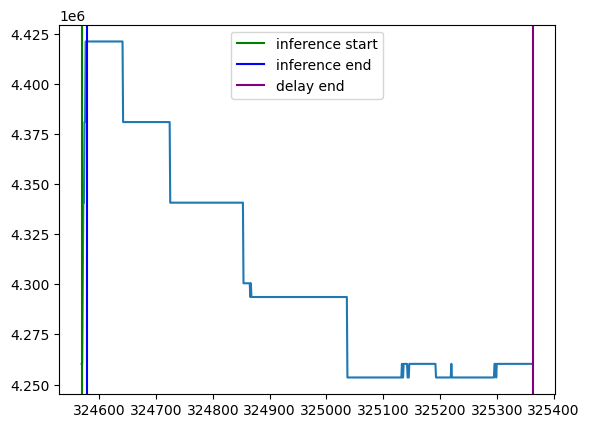

Power values:
Inference start: 4260352.0
Inference end: 4421120.0
Delay end: 4260352.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:23.281663 -> 2025-01-17 12:27:23.291533
2025-01-17 12:27:24.291533
Time taken by inference cycle 8: 0:00:00.009870
Iteration: 8, Power index: 325365 -> 325374
326160


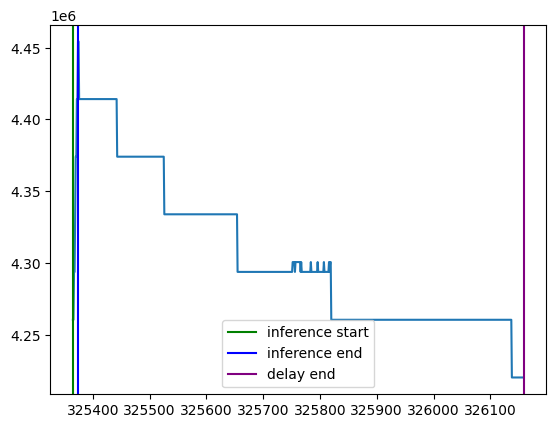

Power values:
Inference start: 4260352.0
Inference end: 4454208.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:24.294052 -> 2025-01-17 12:27:24.303919
2025-01-17 12:27:25.303919
Time taken by inference cycle 9: 0:00:00.009867
Iteration: 9, Power index: 326161 -> 326170
326956


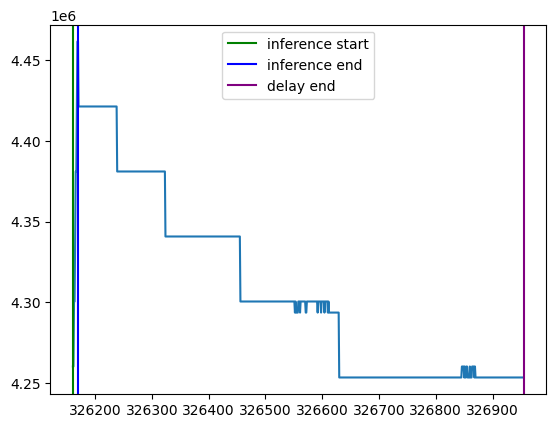

Power values:
Inference start: 4260352.0
Inference end: 4461312.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:25.306438 -> 2025-01-17 12:27:25.316311
2025-01-17 12:27:26.316311
Time taken by inference cycle 10: 0:00:00.009873
Iteration: 10, Power index: 326957 -> 326965
327751


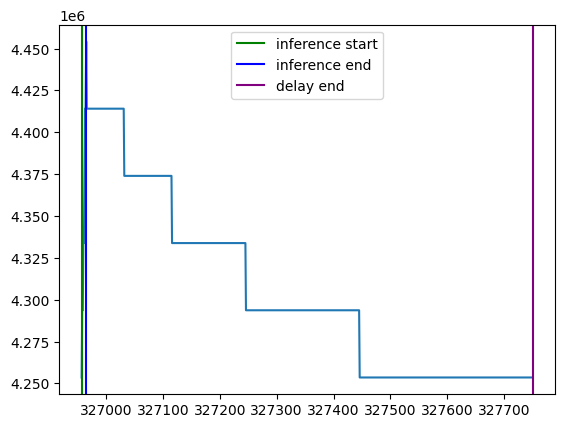

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:26.319117 -> 2025-01-17 12:27:26.328984
2025-01-17 12:27:27.328984
Time taken by inference cycle 11: 0:00:00.009867
Iteration: 11, Power index: 327752 -> 327761
328545


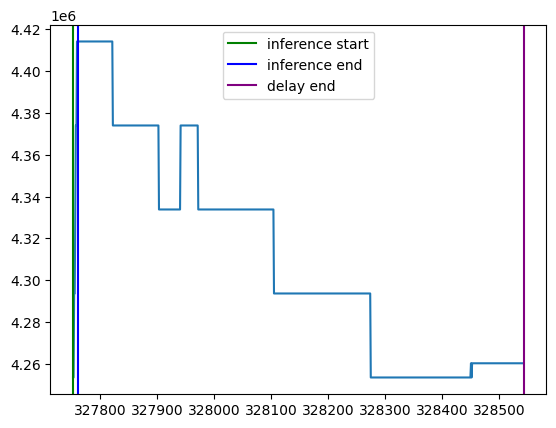

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4260352.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:27.331802 -> 2025-01-17 12:27:27.341654
2025-01-17 12:27:28.341654
Time taken by inference cycle 12: 0:00:00.009852
Iteration: 12, Power index: 328546 -> 328555
329341


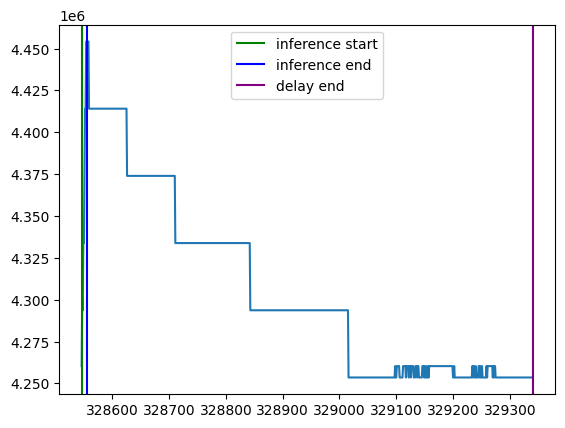

Power values:
Inference start: 4260352.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:28.344194 -> 2025-01-17 12:27:28.354078
2025-01-17 12:27:29.354078
Time taken by inference cycle 13: 0:00:00.009884
Iteration: 13, Power index: 329342 -> 329351
330136


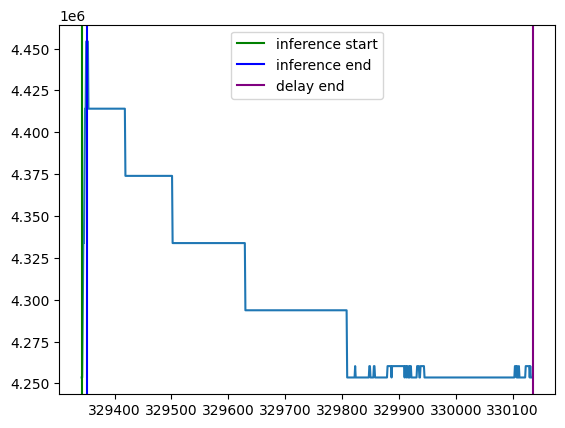

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:27:29.356603 -> 2025-01-17 12:27:29.366482
2025-01-17 12:27:30.366482
Time taken by inference cycle 14: 0:00:00.009879
Iteration: 14, Power index: 330137 -> 330146
330932


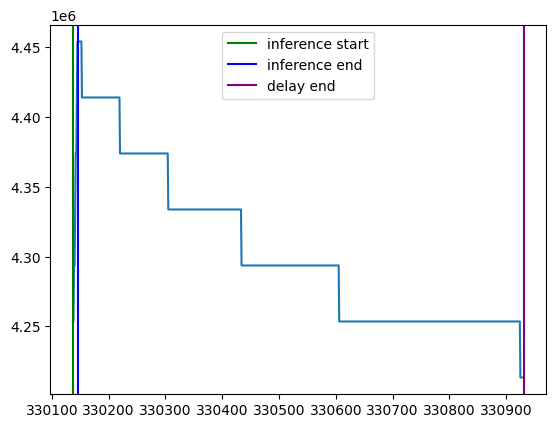

Power values:
Inference start: 4253568.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------


In [16]:
for i in range(15):
    plot_inference_cycle_power(i, vgg19_power_data, vgg19_latency_data, DELAY)

2025-01-17 12:28:56.434096 -> 2025-01-17 12:28:56.443942
2025-01-17 12:28:57.443942
Time taken by inference cycle 100: 0:00:00.009846
Iteration: 100, Power index: 398284 -> 398293
399075


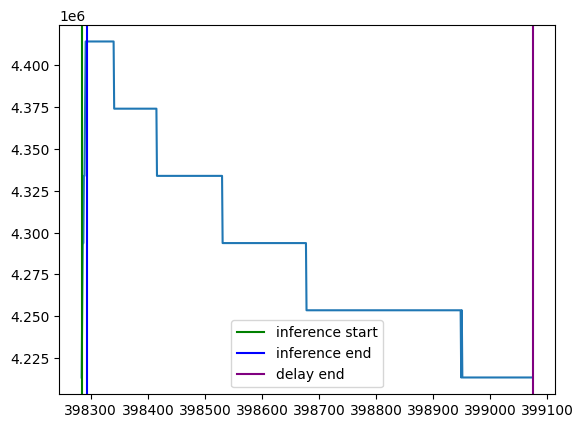

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:28:57.446679 -> 2025-01-17 12:28:57.456456
2025-01-17 12:28:58.456456
Time taken by inference cycle 101: 0:00:00.009777
Iteration: 101, Power index: 399076 -> 399084
399866


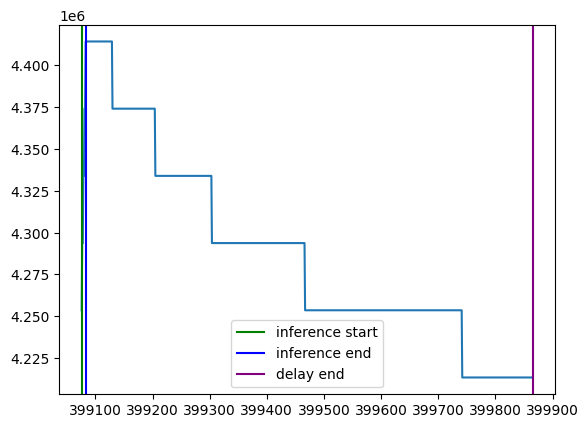

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:28:58.459168 -> 2025-01-17 12:28:58.469016
2025-01-17 12:28:59.469016
Time taken by inference cycle 102: 0:00:00.009848
Iteration: 102, Power index: 399867 -> 399876
400658


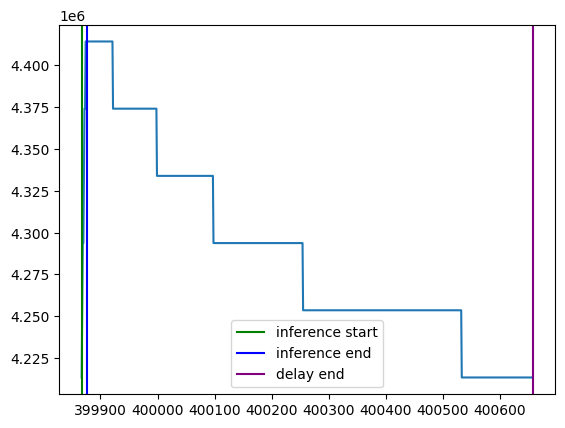

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:28:59.471716 -> 2025-01-17 12:28:59.481560
2025-01-17 12:29:00.481560
Time taken by inference cycle 103: 0:00:00.009844
Iteration: 103, Power index: 400659 -> 400667
401449


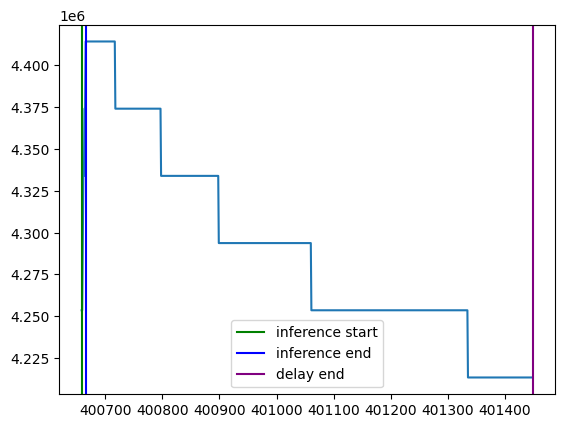

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:00.484069 -> 2025-01-17 12:29:00.493925
2025-01-17 12:29:01.493925
Time taken by inference cycle 104: 0:00:00.009856
Iteration: 104, Power index: 401450 -> 401459
402241


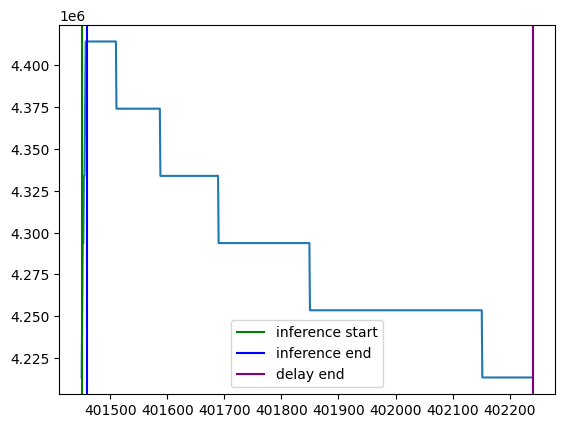

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:01.496099 -> 2025-01-17 12:29:01.505935
2025-01-17 12:29:02.505935
Time taken by inference cycle 105: 0:00:00.009836
Iteration: 105, Power index: 402241 -> 402250
403032


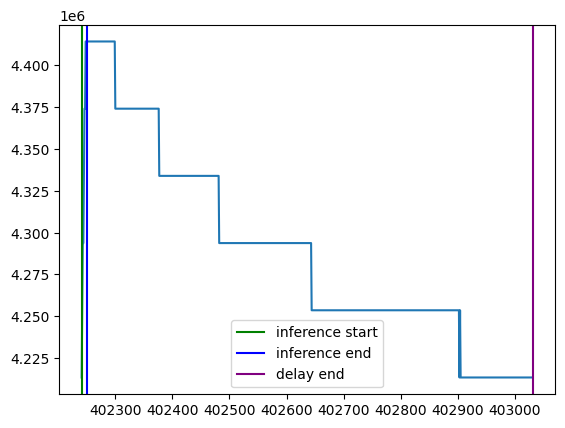

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:02.508082 -> 2025-01-17 12:29:02.517929
2025-01-17 12:29:03.517929
Time taken by inference cycle 106: 0:00:00.009847
Iteration: 106, Power index: 403033 -> 403041
403823


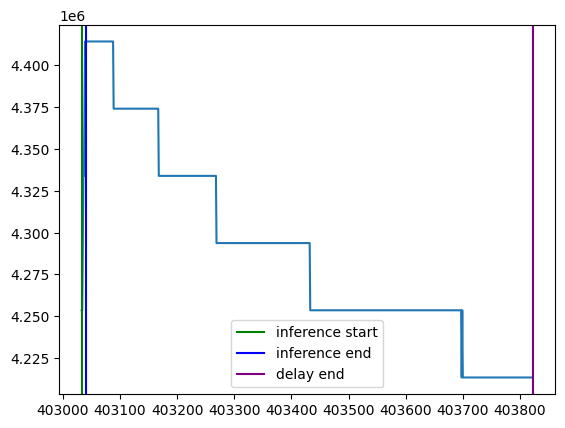

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:03.520104 -> 2025-01-17 12:29:03.529963
2025-01-17 12:29:04.529963
Time taken by inference cycle 107: 0:00:00.009859
Iteration: 107, Power index: 403824 -> 403832
404615


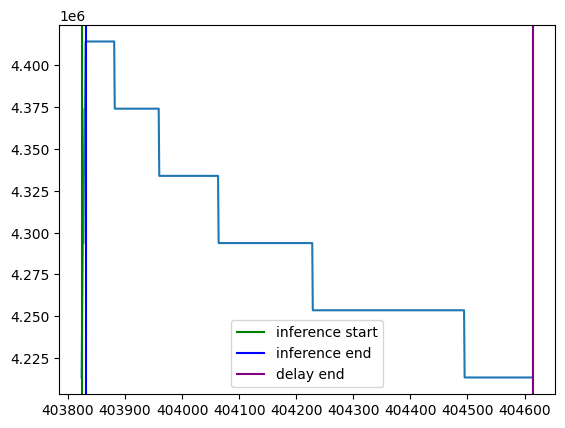

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:04.532153 -> 2025-01-17 12:29:04.542005
2025-01-17 12:29:05.542005
Time taken by inference cycle 108: 0:00:00.009852
Iteration: 108, Power index: 404615 -> 404624
405406


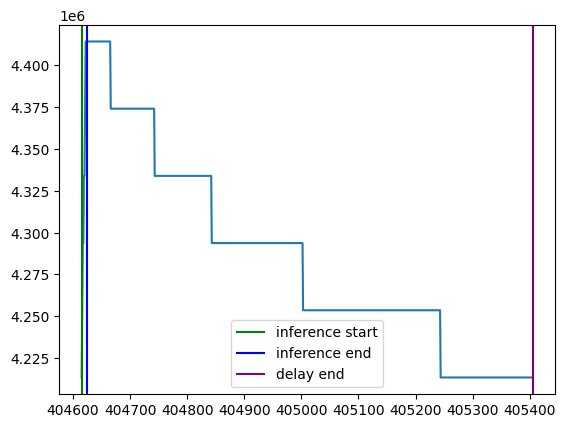

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:05.544148 -> 2025-01-17 12:29:05.553995
2025-01-17 12:29:06.553995
Time taken by inference cycle 109: 0:00:00.009847
Iteration: 109, Power index: 405407 -> 405416
406198


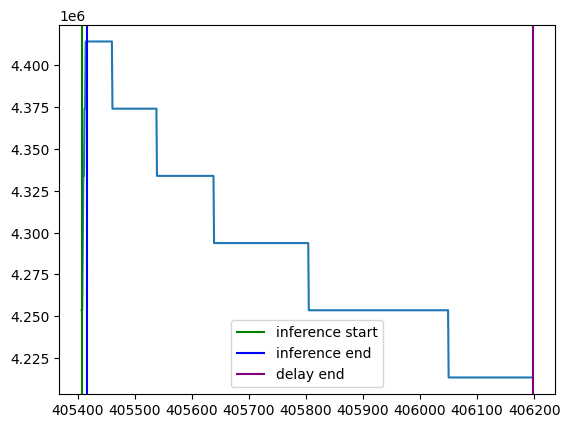

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:06.556116 -> 2025-01-17 12:29:06.565960
2025-01-17 12:29:07.565960
Time taken by inference cycle 110: 0:00:00.009844
Iteration: 110, Power index: 406198 -> 406207
406989


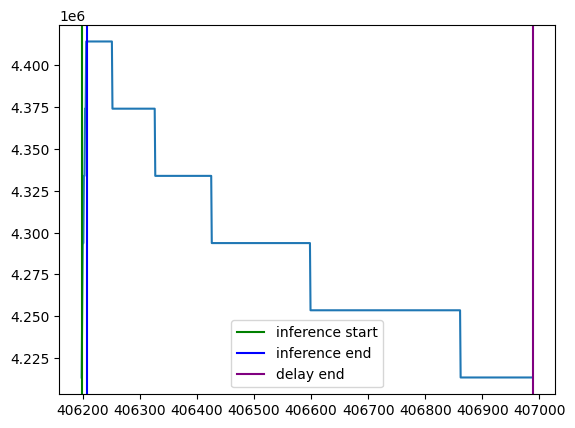

Power values:
Inference start: 4213440.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:07.568633 -> 2025-01-17 12:29:07.578468
2025-01-17 12:29:08.578468
Time taken by inference cycle 111: 0:00:00.009835
Iteration: 111, Power index: 406990 -> 406999
407781


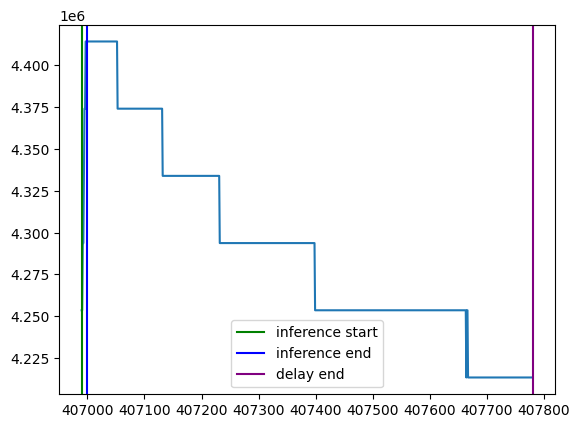

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:08.581146 -> 2025-01-17 12:29:08.590979
2025-01-17 12:29:09.590979
Time taken by inference cycle 112: 0:00:00.009833
Iteration: 112, Power index: 407782 -> 407791
408573


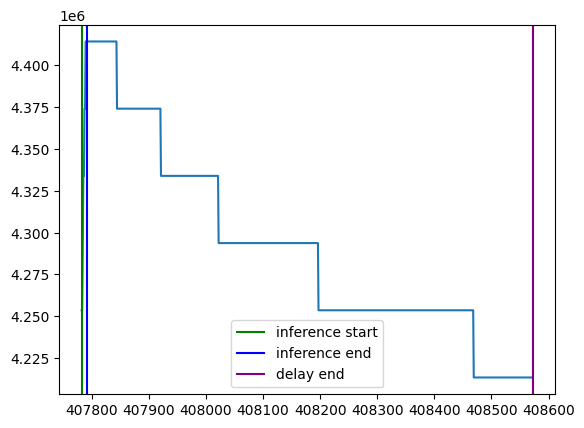

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:09.593646 -> 2025-01-17 12:29:09.603481
2025-01-17 12:29:10.603481
Time taken by inference cycle 113: 0:00:00.009835
Iteration: 113, Power index: 408574 -> 408583
409364


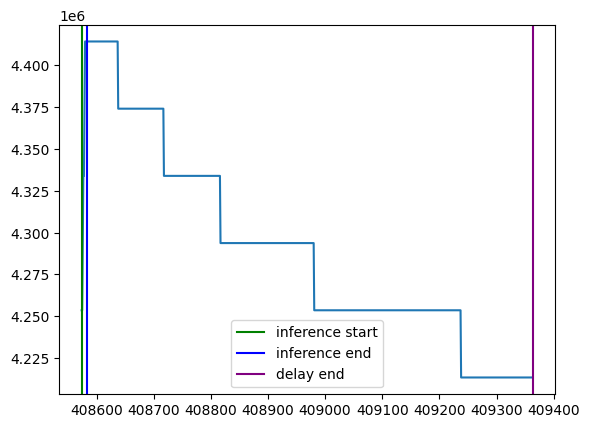

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 12:29:10.606127 -> 2025-01-17 12:29:10.615980
2025-01-17 12:29:11.615980
Time taken by inference cycle 114: 0:00:00.009853
Iteration: 114, Power index: 409366 -> 409374
410156


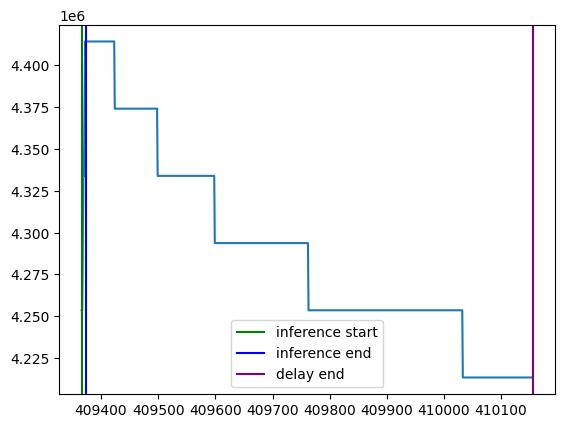

Power values:
Inference start: 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [17]:
for i in range(100, 115):
    plot_inference_cycle_power(i, vgg19_power_data, vgg19_latency_data, DELAY)

## Conclusion

Number of VGG16 TensorRT layers: 37

Most common VGG16 power profile

```
Inference start: 4213440.0 or 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
```

Number of VGG19 TensorRT layers: 40

Most common VGG19 power profile

```
Inference start: 4213440.0 or 4253568.0
Inference end: 4414080.0
Delay end: 4213440.0
```
